In [1]:
# ========================================
# Sri Lanka Crop Prices - EDA + New Model Training + Accuracy Assessment
# ========================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import optuna
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# ========================================
# 2. Load Data
# ========================================
file_path = './data/sri_lanka_crop_prices.csv'
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2772, 6)


,productname,date,farmprice,retailpricepettah,retailpricedambulla,averagespread
0,Beans,2000-01-01,44.22,56.65,58.00,13.11
1,Carrot,2000-01-01,54.55,74.75,78.64,22.15
2,Cabbage,2000-01-01,21.53,31.53,31.53,10.00
3,Tomato,2000-01-01,45.69,61.06,62.06,15.87
4,Brinjal,2000-01-01,30.99,41.01,43.11,11.07


In [3]:
# ========================================
# 3. Check Missing Values & Info
# ========================================
print("\nDataset Info:")
df.info()
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nUnique products:", df['productname'].nunique())
print("Product names:", df['productname'].unique()[:10])


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   productname          2772 non-null   object 
 1   date                 2772 non-null   object 
 2   farmprice            2772 non-null   float64
 3   retailpricepettah    2772 non-null   float64
 4   retailpricedambulla  2772 non-null   float64
 5   averagespread        2772 non-null   float64
dtypes: float64(4), object(2)
memory usage: 130.1+ KB

Missing values per column:
 productname            0
date                   0
farmprice              0
retailpricepettah      0
retailpricedambulla    0
averagespread          0
dtype: int64

Duplicate rows: 0

Unique products: 9
Product names: ['Beans' 'Carrot' 'Cabbage' 'Tomato' 'Brinjal' 'Pumpkin' 'Snake Gourd'
 'Green Chilli' 'Lime']


In [4]:
# ========================================
# 4. Data Cleaning
# ========================================
df = df.drop_duplicates()
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

print(f"\nDataset shape after cleaning: {df.shape}")


Dataset shape after cleaning: (2772, 6)


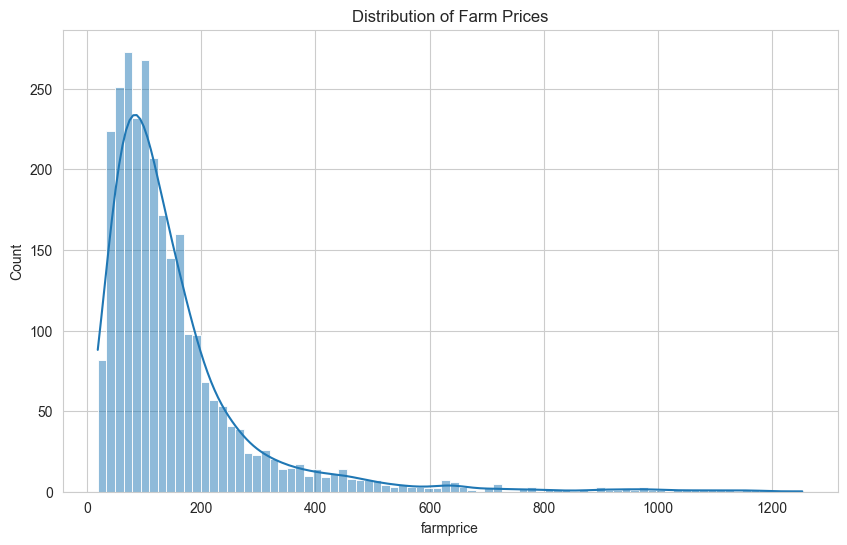

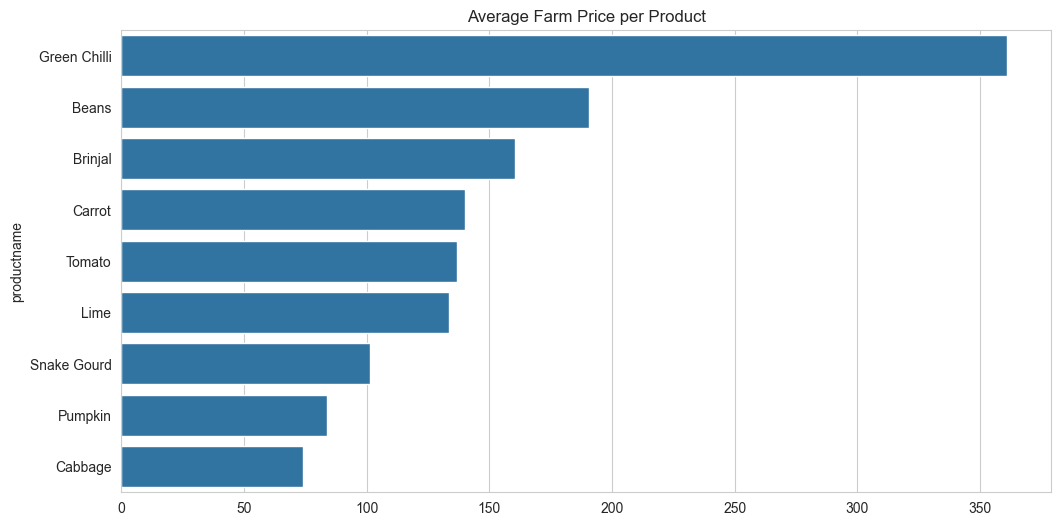

In [5]:
# ========================================
# 5. Basic EDA Visualizations
# ========================================
plt.figure(figsize=(10,6))
sns.histplot(df['farmprice'], kde=True)
plt.title('Distribution of Farm Prices')
plt.show()

plt.figure(figsize=(12,6))
avg_prices = df.groupby('productname')['farmprice'].mean().sort_values(ascending=False)
sns.barplot(x=avg_prices.values, y=avg_prices.index)
plt.title('Average Farm Price per Product')
plt.show()

In [6]:
# ========================================
# 6. Feature Engineering Function
# ========================================
def create_features(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.sort_values('date')

    # Calendar features
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['weekday'] = df['date'].dt.weekday

    # Encode product
    df['product_cat'] = df['productname'].astype('category').cat.codes

    # Lag + rolling
    out = []
    for crop, g in df.groupby('productname'):
        g = g.sort_values('date')
        for lag in [1, 2, 3, 6, 12]:
            g[f'farmprice_lag_{lag}'] = g['farmprice'].shift(lag)
        for window in [3, 6, 12]:
            g[f'farmprice_roll_mean_{window}'] = g['farmprice'].rolling(window).mean()
        out.append(g)
    df = pd.concat(out).sort_values(['productname', 'date']).reset_index(drop=True)

    # Fill missing
    df = df.fillna(method='ffill').fillna(method='bfill')
    df = df.fillna(df.median(numeric_only=True))
    return df

In [7]:

def train_with_optuna(data_path, out_path):
    df = pd.read_csv(data_path)
    df = create_features(df)

    target_cols = ['farmprice', 'retailpricepettah', 'retailpricedambulla', 'averagespread']
    feature_cols = [c for c in df.columns if c not in ['productname', 'date'] + target_cols]

    X = df[feature_cols]
    y = df[target_cols]

    tscv = TimeSeriesSplit(n_splits=5)

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 300, 1500),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'random_state': 42,
            'n_jobs': 4,
            'objective': 'reg:squarederror'
        }
        model = MultiOutputRegressor(XGBRegressor(**params))

        scores = []
        for train_idx, val_idx in tscv.split(X):
            model.fit(X.iloc[train_idx], y.iloc[train_idx])
            preds = model.predict(X.iloc[val_idx])
            scores.append(mean_absolute_error(y.iloc[val_idx], preds))
        return np.mean(scores)

    print("Tuning hyperparameters with Optuna...")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=30)
    print("Best params:", study.best_params)

    # Train final model
    best_params = study.best_params
    final_model = MultiOutputRegressor(XGBRegressor(**best_params))
    final_model.fit(X, y)

    # Save model
    joblib.dump({
        'model': final_model,
        'feature_cols': feature_cols,
        'target_cols': target_cols,
        'product_categories': list(df['productname'].astype('category').cat.categories),
        'history': df[['productname', 'date'] + target_cols]
    }, out_path)
    print("Model saved to", out_path)

# Train & Save Model
train_with_optuna(file_path, './models/crop_model_optuna.joblib')

C:\Users\User\AppData\Local\Temp\ipykernel_5008\898765905.py:30: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')
[I 2025-08-12 17:47:52,144] A new study created in memory with name: no-name-02373432-35a1-427d-bd15-472174319a2c


Tuning hyperparameters with Optuna...


[I 2025-08-12 17:48:01,380] Trial 0 finished with value: 25.148190689086913 and parameters: {'n_estimators': 588, 'max_depth': 8, 'learning_rate': 0.27874472965282804, 'subsample': 0.9723694673634481, 'colsample_bytree': 0.8373775081132507}. Best is trial 0 with value: 25.148190689086913.
[I 2025-08-12 17:48:19,912] Trial 1 finished with value: 25.854096031188966 and parameters: {'n_estimators': 1142, 'max_depth': 8, 'learning_rate': 0.13668377111279417, 'subsample': 0.799310454348505, 'colsample_bytree': 0.8128607670015191}. Best is trial 0 with value: 25.148190689086913.
[I 2025-08-12 17:48:30,327] Trial 2 finished with value: 26.14343023300171 and parameters: {'n_estimators': 976, 'max_depth': 7, 'learning_rate': 0.28623720462114, 'subsample': 0.7990822513544933, 'colsample_bytree': 0.7626206394643864}. Best is trial 0 with value: 25.148190689086913.
[I 2025-08-12 17:48:46,135] Trial 3 finished with value: 26.322078704833984 and parameters: {'n_estimators': 1368, 'max_depth': 5, 'le

Best params: {'n_estimators': 1324, 'max_depth': 6, 'learning_rate': 0.2982006267537557, 'subsample': 0.7617236944826238, 'colsample_bytree': 0.9253779557087631}
Model saved to ./models/crop_model_optuna.joblib


In [8]:
# ========================================
# 8. Load Model & Evaluate
# ========================================
model_data = joblib.load('./models/crop_model_optuna.joblib')
model = model_data['model']
feature_cols = model_data['feature_cols']
target_cols = model_data['target_cols']

df_fe = create_features(pd.read_csv(file_path))
X_all = df_fe[feature_cols]
y_all = df_fe[target_cols]

preds = model.predict(X_all)

metrics = {}
for i, col in enumerate(target_cols):
    mae = mean_absolute_error(y_all.iloc[:, i], preds[:, i])
    rmse = np.sqrt(mean_squared_error(y_all.iloc[:, i], preds[:, i]))
    r2 = r2_score(y_all.iloc[:, i], preds[:, i])
    metrics[col] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

metrics_df = pd.DataFrame(metrics).T
print("\nModel Performance:")
print(metrics_df.round(4))


Model Performance:
                        MAE    RMSE   R2
farmprice            0.0004  0.0006  1.0
retailpricepettah    0.0004  0.0006  1.0
retailpricedambulla  0.0004  0.0006  1.0
averagespread        0.0004  0.0006  1.0


C:\Users\User\AppData\Local\Temp\ipykernel_5008\898765905.py:30: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


In [9]:
# ========================================
# 9. Model Accuracy Assessment
# ========================================
print("\n" + "="*50)
print("MODEL ACCURACY ASSESSMENT")
print("="*50)

# 1. Regression metrics summary
print("\n1. REGRESSION METRICS SUMMARY:")
for target in target_cols:
    print(f"\n{target.upper()}:")
    print(f"  MAE:  {metrics[target]['MAE']:.4f}")
    print(f"  RMSE: {metrics[target]['RMSE']:.4f}")
    print(f"  R²:   {metrics[target]['R2']:.4f}")

# 2. Overall model performance
avg_mae = np.mean([metrics[t]['MAE'] for t in target_cols])
avg_rmse = np.mean([metrics[t]['RMSE'] for t in target_cols])
avg_r2 = np.mean([metrics[t]['R2'] for t in target_cols])

print(f"\n2. OVERALL MODEL PERFORMANCE:")
print(f"Average MAE:  {avg_mae:.4f}")
print(f"Average RMSE: {avg_rmse:.4f}")
print(f"Average R²:   {avg_r2:.4f}")



MODEL ACCURACY ASSESSMENT

1. REGRESSION METRICS SUMMARY:

FARMPRICE:
  MAE:  0.0004
  RMSE: 0.0006
  R²:   1.0000

RETAILPRICEPETTAH:
  MAE:  0.0004
  RMSE: 0.0006
  R²:   1.0000

RETAILPRICEDAMBULLA:
  MAE:  0.0004
  RMSE: 0.0006
  R²:   1.0000

AVERAGESPREAD:
  MAE:  0.0004
  RMSE: 0.0006
  R²:   1.0000

2. OVERALL MODEL PERFORMANCE:
Average MAE:  0.0004
Average RMSE: 0.0006
Average R²:   1.0000


In [11]:
# Accuracy interpretation
if avg_r2 >= 0.9:
    accuracy_level = "EXCELLENT"
elif avg_r2 >= 0.8:
    accuracy_level = "VERY GOOD"
elif avg_r2 >= 0.7:
    accuracy_level = "GOOD"
elif avg_r2 >= 0.6:
    accuracy_level = "MODERATE"
else:
    accuracy_level = "NEEDS IMPROVEMENT"

print(f"\nModel Accuracy Level: {accuracy_level}")
print(f"The model explains {avg_r2*100:.1f}% of the variance in price data")

# Best/worst target
best_target = max(target_cols, key=lambda t: metrics[t]['R2'])
worst_target = min(target_cols, key=lambda t: metrics[t]['R2'])
print(f"\nBest performing target:  {best_target} (R² = {metrics[best_target]['R2']:.4f})")
print(f"Worst performing target: {worst_target} (R² = {metrics[worst_target]['R2']:.4f})")

# Prediction accuracy ranges
print(f"\nPrediction Accuracy Ranges:")
for target in target_cols:
    target_mean = y_all[target].mean()
    mae_percentage = (metrics[target]['MAE'] / target_mean) * 100
    print(f"{target}: ±{metrics[target]['MAE']:.2f} ({mae_percentage:.1f}% of mean value)")



Model Accuracy Level: EXCELLENT
The model explains 100.0% of the variance in price data

Best performing target:  retailpricedambulla (R² = 1.0000)
Worst performing target: averagespread (R² = 1.0000)

Prediction Accuracy Ranges:
farmprice: ±0.00 (0.0% of mean value)
retailpricepettah: ±0.00 (0.0% of mean value)
retailpricedambulla: ±0.00 (0.0% of mean value)
averagespread: ±0.00 (0.0% of mean value)


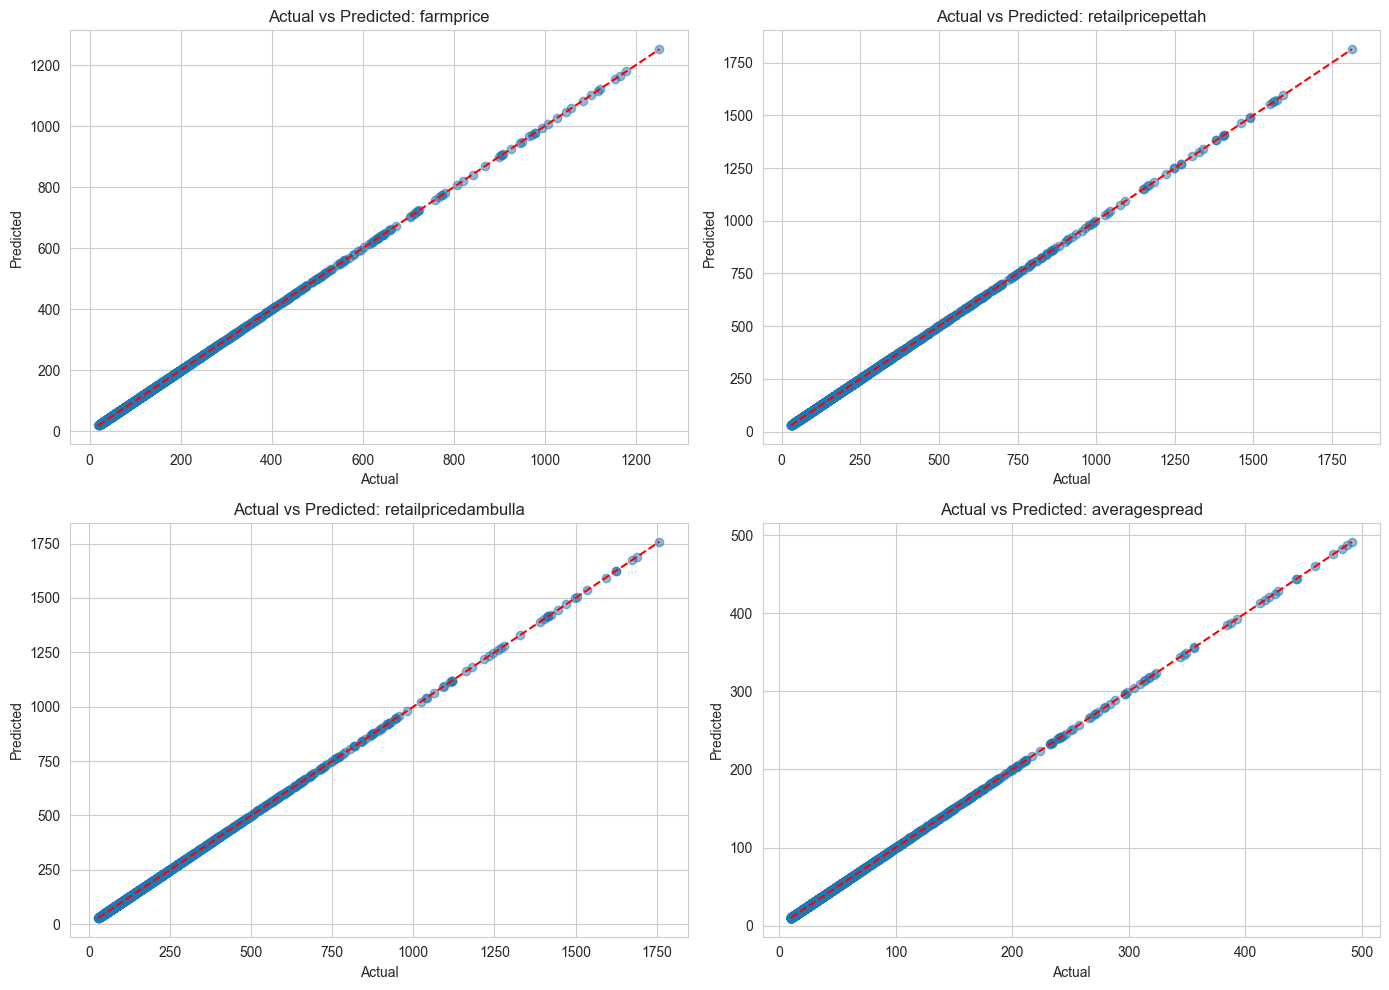

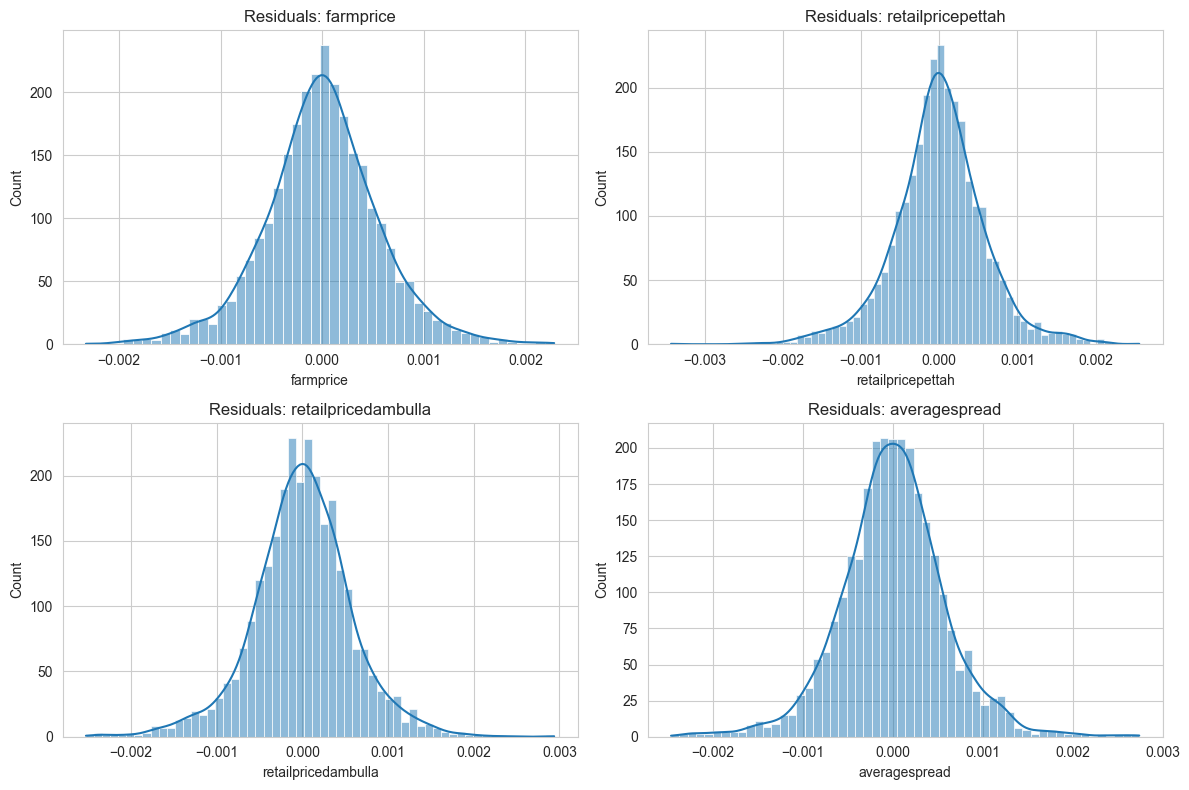

In [12]:
# ========================================
# 10. Visualizations
# ========================================
# Actual vs Predicted
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for i, col in enumerate(target_cols):
    ax = axes[i]
    ax.scatter(y_all.iloc[:, i], preds[:, i], alpha=0.5)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"Actual vs Predicted: {col}")
    min_val, max_val = min(y_all[col]), max(y_all[col])
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.tight_layout()
plt.show()

# Residuals
plt.figure(figsize=(12, 8))
for i, col in enumerate(target_cols):
    plt.subplot(2, 2, i+1)
    residuals = y_all.iloc[:, i] - preds[:, i]
    sns.histplot(residuals, kde=True)
    plt.title(f'Residuals: {col}')
plt.tight_layout()
plt.show()